In [ ]:
from collections.abc import Callable
from pathlib import Path

import equinox as eqx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import optax
import xarray as xr
from context_flux_no.models.fluxfno import FluxFNO1D
from context_flux_no.nn.operators.fourier_utils import append_grid_channels
from context_flux_no.training import PDEDataset, RandomMiniBatching, SegmentLoader
from einops import rearrange
from jaxtyping import Array, Float, PRNGKeyArray, PyTree


# jax.config.update("jax_enable_x64", True)

datadir = Path("../../data")


In [ ]:
dataset_xr = xr.load_dataset(datadir / "burgers_train.hdf5", engine="h5netcdf")
dataset_xr

In [2]:
dataset = PDEDataset.from_xarray(dataset_xr.sel(t=slice(None, None, 10)))

In [12]:
test_arr = jnp.reshape(jnp.arange(10.0), (1, -1))
print(test_arr.shape)
stencil_size = (2, 2)
test_padded = jnp.pad(test_arr, pad_width=[(0, 0), stencil_size], mode="wrap")
print(test_padded.shape)

(1, 10)
(1, 14)


In [13]:
jax.lax.conv_general_dilated_patches(
    jnp.expand_dims(test_padded, axis=0), (sum(stencil_size) + 1,), (1,), "valid"
).shape

(1, 5, 10)

In [ ]:
class FluxNO1D(eqx.Module):
    in_channels: int = eqx.field(static=True)
    stencil_widths: tuple[int, int] = eqx.field(static=True)

    def __init__(
        self, in_channels: int, out_channels: int, stencil_widths: tuple[int, int]
    ):
        pass

    @property
    def stencil_size(self) -> int:
        return sum(self.stencil_widths) + 1

    def get_stencils(
        self, u: Float[Array, "channels grid_x"]
    ) -> Float[Array, "channels {self.stencil_size} grids_x+1"]:
        a, b = self.stencil_widths
        pad_widths = [(0, 0), (a, b + 1)]
        # Need to change mode if not periodic boundary condition
        u_padded = jnp.pad(u, pad_widths, mode="wrap")
        u_stencils = jax.lax.conv_general_dilated_patches(
            jnp.expand_dims(u_padded, axis=0),  # Requires a dummy batch axis
            filter_shape=(self.stencil_size,),
            window_strides=(1,),
            padding="valid",
        )[0]  # Remove the batch axis
        return rearrange(u_stencils, "(c s) ... -> c s ...", c=u.shape[0])

    def compute_flux(
        self, u_stencils: Float[Array, "channels {self.stencil_size} grids_x+1"]
    ) -> Float[Array, "channels grids_x+1"]:
        pass

    def __call__(
        self, u: Float[Array, "channels grids_x"], dx: float, *, key: PRNGKeyArray
    ) -> Float[Array, "channels grids_x"]:
        u: Float[Array, "channels+1 grids_x"] = append_grid_channels(u)
        u_stencils: Float[Array, "channels+1 {self.stencil_size} grids_x"] = (
            self.get_stencils(u)
        )
        f: Float[Array, "channels grids_x+1"] = self.compute_flux(u_stencils)
        du_dt: Float[Array, "channels grids_x"] = -jnp.diff(f, axis=1) / dx
        return u + du_dt * dt

In [ ]:
def train(
    model: eqx.Module,
    dataloader: SegmentLoader,
    optimizer: optax.GradientTransformation,
    loss_fn: Callable[[eqx.Module, PyTree[Array]], Float[Array, ""]],
    max_steps: int,
):
    loss_grad_fn = eqx.filter_value_and_grad(loss_fn, has_aux=True)

    @eqx.filter_jit
    def train_step(model_, loader_state_, opt_state_):
        batch, loader_state_ = dataloader.load_batch(loader_state_)

        (loss, aux), grads = loss_grad_fn(model_, batch)
        updates, opt_state_ = optimizer.update(
            grads, opt_state_, eqx.filter(model_, eqx.is_array)
        )
        model_ = eqx.apply_updates(model_, updates)
        return loss, aux, model_, loader_state_, opt_state_

    loader_state = dataloader.init()
    opt_state = optimizer.init(eqx.filter(model, eqx.is_array))
    loss_history = []
    for i in range(max_steps):
        loss, aux, model, loader_state, opt_state = train_step(
            model, loader_state, opt_state
        )
        ## Logging and save logic
        loss_ = loss.item()
        print(f"Step: {i}: loss = {loss_}")
        loss_history.append(loss_)
    return model, jnp.asarray(loss_history)

In [4]:
loader = SegmentLoader(dataset, 2, RandomMiniBatching(1024))

In [5]:
loader_state = loader.init()
batch, loader_state = loader.load_batch(loader_state)

In [6]:
model = FluxFNO1D(
    data_dim=1,
    lift_dim=64,
    depth=4,
    frequency_modes=8,
    stencil_size=2,
    key=jax.random.key(0),
)

In [7]:
from typing import Any


def mean_squared_error(model, batch) -> tuple[Float[Array, ""], Any]:
    u_batch, t_batch, x_batch, _ = batch
    dt, dx = t_batch[0, 1] - t_batch[0, 0], x_batch[0, 1] - x_batch[0, 0]
    u0, u1 = u_batch[:, 0], u_batch[:, 1]
    u1_pred: Float[Array, "batch dim x"] = eqx.filter_vmap(
        model, in_axes=(0, None, None)
    )(u0, dt, dx)
    return jnp.mean((u1_pred - u1) ** 2), None


In [8]:
mean_squared_error(model, batch)

2025-10-08 00:40:41.684091: E external/xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng28{k2=4,k3=0} for conv %cudnn-conv = (f64[1024,64,256]{2,1,0}, u8[0]{0}) custom-call(%Arg_0.1, %Arg_1.2), window={size=1}, dim_labels=bf0_oi0->bf0, custom_call_target="__cudnn$convForward", metadata={op_name="jit(conv_general_dilated)/jit(main)/conv_general_dilated" source_file="/home/jhko725/projects/CONTEXT_FLUX_NO/.venv/lib/python3.12/site-packages/equinox/nn/_conv.py" source_line=238}, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"conv_result_scale":1,"activation_mode":"kNone","side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]} is taking a while...
2025-10-08 00:40:42.568521: E external/xla/xla/service/slow_operation_alarm.cc:140] The operation took 1.884593275s
Trying algorithm eng28{k2=4,k3=0} for conv %cudnn-conv = (f64[1024,64,256]{2,1,0}, u8[0]{0}) custom-call(%Arg_0.1, %Arg_1.

(Array(0.00642087, dtype=float64), None)

In [9]:
model_trained, loss_history = train(
    model, loader, optax.adabelief(1e-3), mean_squared_error, max_steps=2000
)

Step: 0: loss = 0.0064208716521821346
Step: 1: loss = 0.007042810570150769
Step: 2: loss = 0.006938117238135573
Step: 3: loss = 0.006116812023932707
Step: 4: loss = 0.006555522131767522
Step: 5: loss = 0.0065747121645381955
Step: 6: loss = 0.006761820186348494
Step: 7: loss = 0.006607875403755407
Step: 8: loss = 0.006759140528267191
Step: 9: loss = 0.005865004534561532
Step: 10: loss = 0.006129237180052378
Step: 11: loss = 0.006573246731329946
Step: 12: loss = 0.0058635689739559285
Step: 13: loss = 0.005271581705076517
Step: 14: loss = 0.004110974226937954
Step: 15: loss = 0.003245870423047021
Step: 16: loss = 0.002812387099478079
Step: 17: loss = 0.003409808306482666
Step: 18: loss = 0.0030938703620007487
Step: 19: loss = 0.002493215174213458
Step: 20: loss = 0.0023434790517333475
Step: 21: loss = 0.002238826415690012
Step: 22: loss = 0.002171235615800197
Step: 23: loss = 0.0022245075467948673
Step: 24: loss = 0.0021762436074545958
Step: 25: loss = 0.0018288907640290838
Step: 26: loss

Text(0, 0.5, 'Train loss')

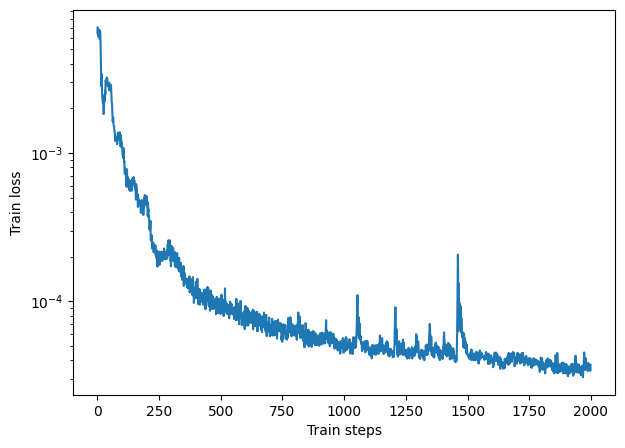

In [10]:
fig, ax = plt.subplots(1, 1, figsize=(7, 5))
ax.plot(loss_history)
ax.set_yscale("log", base=10)
ax.set_xlabel("Train steps")
ax.set_ylabel("Train loss")

Text(0, 0.5, '$u_{pred}-u_{data}$')

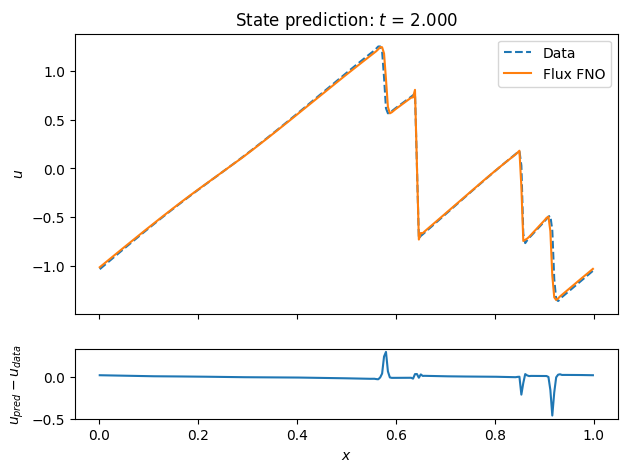

In [11]:
sample_idx = 0
time_idx = 500
u0 = batch[0][sample_idx, time_idx]
u1 = batch[0][sample_idx, time_idx + 1]
dt = batch[1][0, 1] - batch[1][0, 0]

x = batch[2][0]
dx = x[1] - x[0]

fig, axes = plt.subplots(2, 1, figsize=(7, 5), sharex=True, height_ratios=(4, 1))

u1_pred = model_trained(u0, dt, dx)[0]
axes[0].plot(x, u1[0], "--", label="Data")
axes[0].plot(x, u1_pred, label="Flux FNO")
axes[0].legend()

axes[0].set_ylabel("$u$")
axes[0].set_title(f"State prediction: $t$ = {time_idx * float(dt):3.3f}")
axes[1].plot(x, u1_pred - u1[0])
axes[1].set_xlabel("$x$")
axes[1].set_ylabel("$u_{pred}-u_{data}$")

Text(0.5, 1.0, 'Flux prediction: $t$ = 0.400')

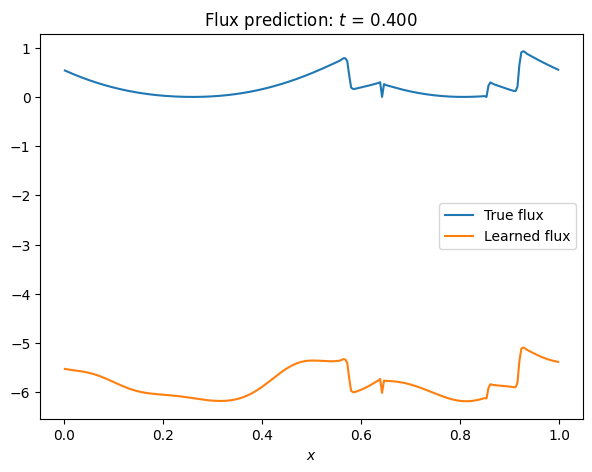

In [12]:
time_idx = 100
f_pred = model_trained.physical_flux(u0)
f_true = 0.5 * u0**2
fig, ax = plt.subplots(1, 1, figsize=(7, 5))
ax.plot(x, f_true[0], label="True flux")
ax.plot(x, f_pred[0], label="Learned flux")
ax.legend()
ax.set_xlabel("$x$")
ax.set_title(f"Flux prediction: $t$ = {time_idx * float(dt):3.3f}")